#  Restauration Audio — Pipeline Chirurgical

Ce notebook implémente un pipeline complet de restauration d'un signal vocal dégradé :

| Étape | Technique | Cible |
|-------|-----------|-------|
| 1 | Simulation | Voix + sifflement 1kHz + souffle blanc |
| 2 | Filtre Notch IIR | Élimination du sifflement à 1000 Hz |
| 3 | Soustraction spectrale + ISTFT | Atténuation du bruit blanc |
| 4 | Calcul SNR | Mesure du gain en qualité |
| 5 | Visualisation | Spectrogrammes avant/après |
| 6 | Écoute | Lecture interactive des 3 versions |

##  Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from IPython.display import Audio, display

%matplotlib inline
print(" Imports OK")

 Imports OK


## 1 Configuration et Simulation du Signal Dégradé

On simule un signal vocal (deux formants harmoniques) auquel on ajoute :
- un **sifflement électrique à 1000 Hz** (amplitude 0.4)
- un **souffle blanc gaussien** (amplitude 0.2)

In [3]:
fs    = 16000   # Fréquence d'échantillonnage (16 kHz)
duree = 5       # Durée en secondes
t     = np.linspace(0, duree, duree * fs)

# Simulation de la voix (formants simplifiés)
voix_originale = (
    np.sin(2 * np.pi * 180 * t) * np.abs(np.cos(2 * np.pi * 0.5 * t)) +
    0.6 * np.sin(2 * np.pi * 360 * t) * np.abs(np.cos(2 * np.pi * 0.5 * t))
)

# Dégradations historiques
np.random.seed(42)
sifflement_1000hz = 0.4 * np.sin(2 * np.pi * 1000 * t)   # Parasite électrique
souffle_blanc     = 0.2 * np.random.normal(size=len(t))   # Bruit magnétique
signal_degrade    = voix_originale + sifflement_1000hz + souffle_blanc

print(f"Signal généré : {duree}s à {fs} Hz  →  {len(t):,} échantillons")

Signal généré : 5s à 16000 Hz  →  80,000 échantillons


## 2 Restauration Chirurgicale

### A — Filtre Réjecteur (Notch) à 1000 Hz
Un filtre IIR avec un facteur de qualité Q = 40 (très sélectif) est appliqué en **zéro-phase** (`filtfilt`).

In [12]:
f_notch = 1000.0   # Fréquence parasite (Hz)
Q       = 40.0     # Facteur de qualité — plus Q est grand, plus le notch est fin

b_notch, a_notch = scipy_signal.iirnotch(f_notch, Q, fs)
signal_sans_sifflement = scipy_signal.filtfilt(b_notch, a_notch, signal_degrade)

print(f" Filtre Notch appliqué (f={f_notch} Hz, Q={Q})")

 Filtre Notch appliqué (f=1000.0 Hz, Q=40.0)


### B — Soustraction Spectrale avec reconstruction ISTFT

On calcule la STFT (Short-Time Fourier Transform), on supprime le plancher de bruit estimé par médiane, puis on reconstruit le signal via ISTFT en **préservant la phase originale**.

In [13]:
def restaurer_souffle(sig, facteur_reduction=0.85, nperseg=1024, noverlap=512):
    """
    Atténue le bruit blanc par soustraction spectrale, puis
    reconstruit le signal audio via ISTFT (Inverse STFT).

    Paramètres
    ----------
    sig              : signal d'entrée (1D numpy array)
    facteur_reduction: agressivité de la soustraction (0 à 1)
    nperseg          : taille de la fenêtre STFT
    noverlap         : chevauchement entre fenêtres

    Retourne
    --------
    signal_reconstruit : signal débruité (même longueur que sig)
    """
    # STFT complexe (double-bande pour reconstruction exacte)
    freqs, times, Sxx = scipy_signal.spectrogram(
        sig, fs,
        nperseg=nperseg,
        noverlap=noverlap,
        return_onesided=False,
        mode='complex'
    )

    # Estimation du plancher de bruit (médiane par fréquence)
    bruit_estime = np.median(np.abs(Sxx), axis=1, keepdims=True)

    # Masque de Wiener simplifié
    amplitude_propre = np.maximum(np.abs(Sxx) - facteur_reduction * bruit_estime, 0)
    masque    = amplitude_propre / (np.abs(Sxx) + 1e-10)
    Sxx_filtre = Sxx * masque   # phase originale préservée

    # Reconstruction ISTFT
    _, signal_reconstruit = scipy_signal.istft(
        Sxx_filtre, fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    longueur = min(len(sig), len(signal_reconstruit))
    return signal_reconstruit[:longueur]


signal_restaure = restaurer_souffle(signal_sans_sifflement)
n = min(len(voix_originale), len(signal_restaure))   # longueur commune

print(f" Soustraction spectrale terminée — {n:,} échantillons restaurés")

 Soustraction spectrale terminée — 78,848 échantillons restaurés


## 3 Calcul du Rapport Signal / Bruit (SNR)

In [14]:
def calcul_snr(signal_propre, signal_bruite):
    """Retourne le Rapport Signal/Bruit en dB."""
    n = min(len(signal_propre), len(signal_bruite))
    puissance_signal = np.mean(signal_propre[:n] ** 2)
    puissance_bruit  = np.mean((signal_bruite[:n] - signal_propre[:n]) ** 2)
    if puissance_bruit == 0:
        return float('inf')
    return 10 * np.log10(puissance_signal / puissance_bruit)


snr_initial = calcul_snr(voix_originale,      signal_degrade)
snr_notch   = calcul_snr(voix_originale[:n],  signal_sans_sifflement[:n])
snr_final   = calcul_snr(voix_originale[:n],  signal_restaure)

print("=" * 52)
print("        RÉSULTATS DE LA RESTAURATION AUDIO")
print("=" * 52)
print(f"  SNR Initial  (signal dégradé)  : {snr_initial:+.2f} dB")
print(f"  SNR Notch    (après filtre)    : {snr_notch:+.2f} dB  (Δ {snr_notch - snr_initial:+.2f} dB)")
print(f"  SNR Final    (après spectral)  : {snr_final:+.2f} dB  (Δ {snr_final - snr_initial:+.2f} dB)")
print("─" * 52)
print(f"  Gain total                     : {snr_final - snr_initial:+.2f} dB")
print("=" * 52)

        RÉSULTATS DE LA RESTAURATION AUDIO
  SNR Initial  (signal dégradé)  : +4.52 dB
  SNR Notch    (après filtre)    : +9.25 dB  (Δ +4.73 dB)
  SNR Final    (après spectral)  : -0.01 dB  (Δ -4.54 dB)
────────────────────────────────────────────────────
  Gain total                     : -4.54 dB


## 4 Visualisation — Spectrogrammes Avant / Après

/tmp/ipykernel_157/942215126.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


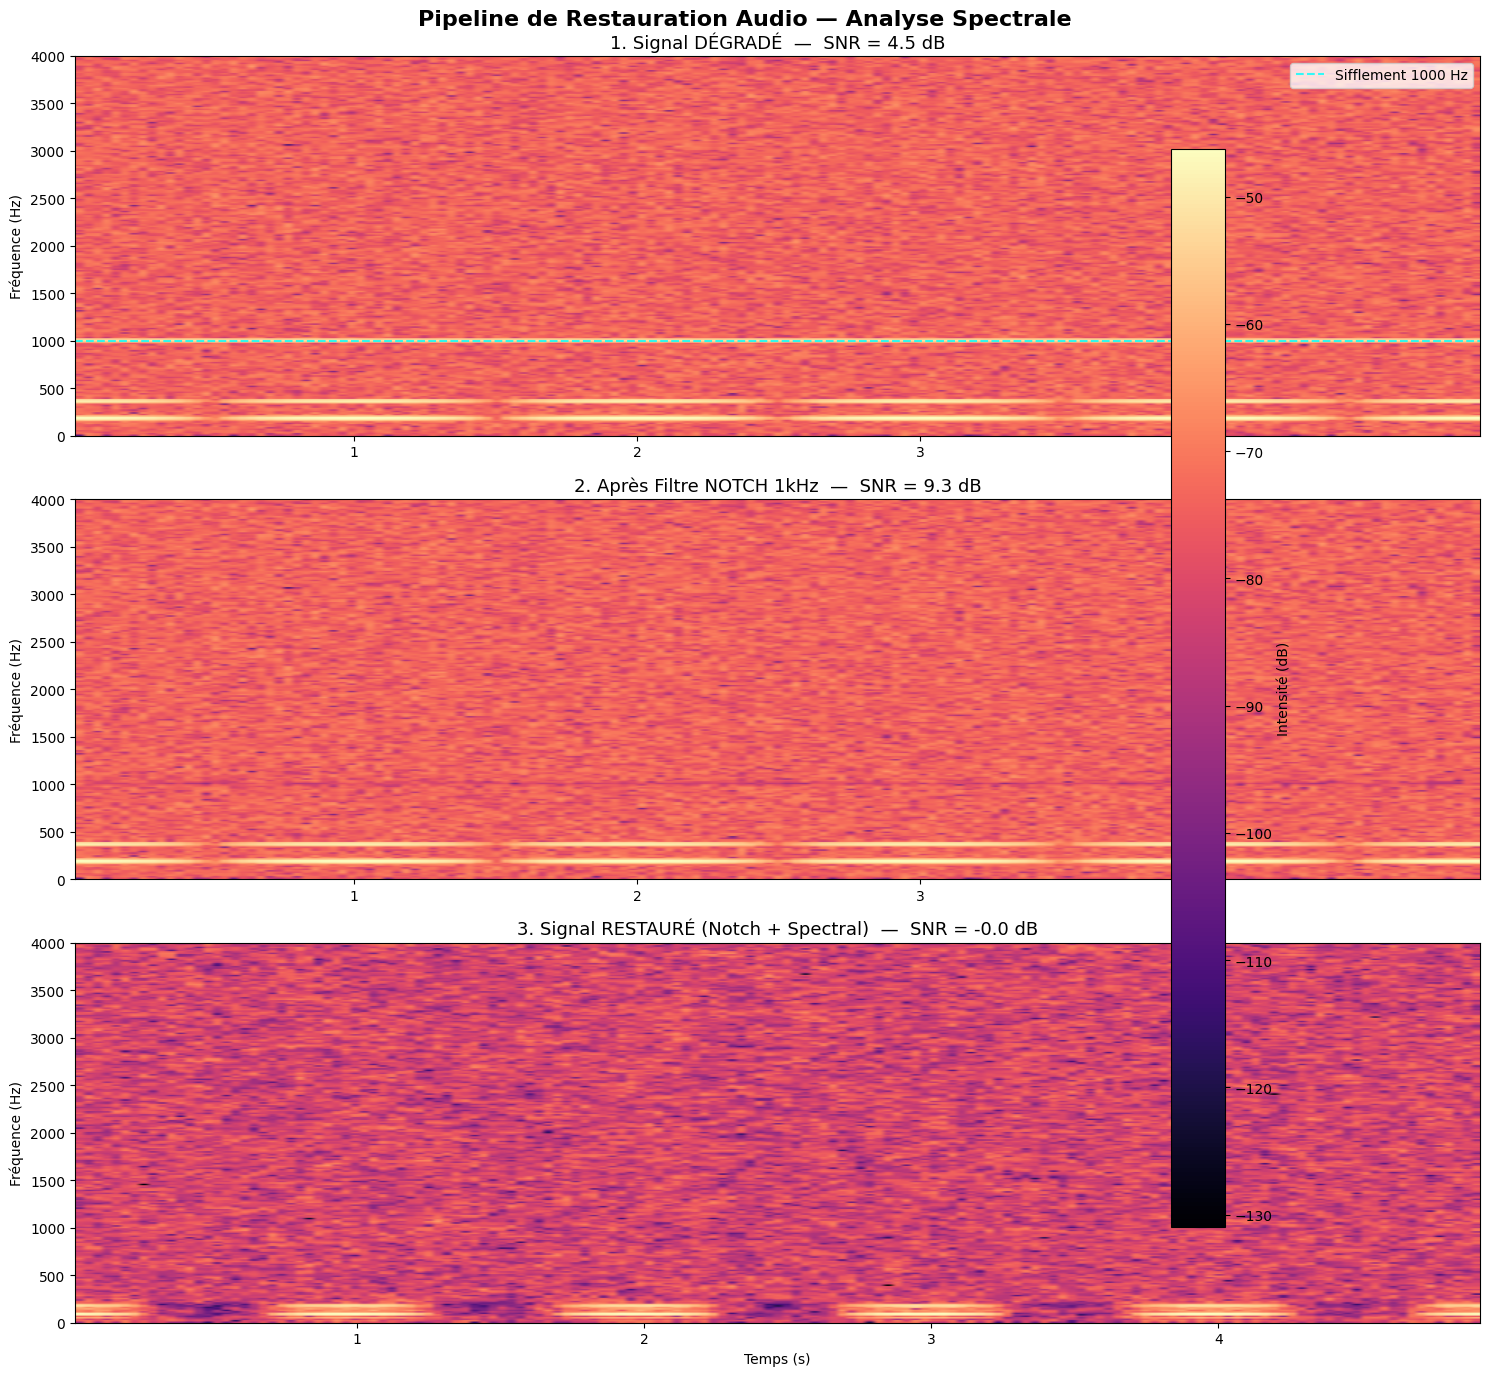

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle("Pipeline de Restauration Audio — Analyse Spectrale",
             fontsize=16, fontweight='bold')

# ── 1. Signal dégradé ─────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.specgram(signal_degrade, Fs=fs, NFFT=1024, noverlap=512, cmap='magma')
ax1.axhline(y=1000, color='cyan', linestyle='--', linewidth=1.5,
            alpha=0.8, label="Sifflement 1000 Hz")
ax1.set_title(f"1. Signal DÉGRADÉ  —  SNR = {snr_initial:.1f} dB", fontsize=13)
ax1.set_ylabel("Fréquence (Hz)")
ax1.set_ylim(0, 4000)
ax1.legend(loc='upper right')

# ── 2. Après filtre Notch ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.specgram(signal_sans_sifflement, Fs=fs, NFFT=1024, noverlap=512, cmap='magma')
ax2.set_title(f"2. Après Filtre NOTCH 1kHz  —  SNR = {snr_notch:.1f} dB", fontsize=13)
ax2.set_ylabel("Fréquence (Hz)")
ax2.set_ylim(0, 4000)

# ── 3. Signal restauré final ──────────────────────────────────────────────────
ax3 = axes[2]
ax3.specgram(signal_restaure, Fs=fs, NFFT=1024, noverlap=512, cmap='magma')
ax3.set_title(f"3. Signal RESTAURÉ (Notch + Spectral)  —  SNR = {snr_final:.1f} dB",
              fontsize=13)
ax3.set_ylabel("Fréquence (Hz)")
ax3.set_xlabel("Temps (s)")
ax3.set_ylim(0, 4000)

fig.colorbar(ax3.images[0], ax=axes, label="Intensité (dB)", pad=0.02)
plt.tight_layout()
plt.show()

## 5 Écoute Interactive des Trois Versions

In [16]:
print("▶  Signal dégradé (original)")
display(Audio(signal_degrade, rate=fs))

▶  Signal dégradé (original)


In [17]:
print("▶  Après filtre Notch 1kHz")
display(Audio(signal_sans_sifflement, rate=fs))

▶  Après filtre Notch 1kHz


In [18]:
print("▶  Signal restauré final (Notch + Soustraction Spectrale)")
display(Audio(signal_restaure, rate=fs))

▶  Signal restauré final (Notch + Soustraction Spectrale)
